# Task 1: Foundational Setup & Exploratory Data Analysis (EDA)
### Dataset: Sample Superstore Sales
**apexplanet-data-analytics**

This notebook covers:
1. Environment / library check
2. Loading the raw dataset
3. Data cleaning
4. Exploratory Data Analysis (EDA)
5. Key business insights


## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

print("pandas", pd.__version__)
print("numpy", np.__version__)

pandas 3.0.2
numpy 2.4.4


## 2. Load Raw Data

In [2]:
raw = pd.read_csv("../data/Sample-Superstore.csv", encoding="utf-8-sig")
print(raw.shape)
raw.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Initial profiling

In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
raw.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [5]:
raw.duplicated().sum()

np.int64(0)

In [6]:
raw.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Data Cleaning

Steps applied (see `scripts/clean_data.py` for the reusable version):
- Standardize column names to snake_case
- Parse `Order Date` / `Ship Date` as datetime
- Cast `Postal Code` to a nullable integer (11 missing values left as-is; not needed for sales/profit analysis)
- Drop exact duplicate rows (0 found)
- Engineer helper columns: `order_year`, `order_month`, `order_year_month`, `shipping_days`, `profit_margin`, `is_loss`


In [7]:
df = raw.copy()
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]

df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
df["postal_code"] = df["postal_code"].astype("Int64")

df = df.drop_duplicates()

df["order_year"] = df["order_date"].dt.year
df["order_month"] = df["order_date"].dt.month
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["profit_margin"] = (df["profit"] / df["sales"]).round(4)
df["is_loss"] = df["profit"] < 0

df.to_csv("../data/superstore_clean.csv", index=False)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_year,order_month,order_year_month,shipping_days,profit_margin,is_loss
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2017,11,2017-11,3,0.1600,False
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2017,11,2017-11,3,0.3000,False
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2017,6,2017-06,4,0.4700,False
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2016,10,2016-10,7,-0.4000,True
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2016,10,2016-10,7,0.1125,False


### (Optional) Load into SQLite via SQLAlchemy — demonstrates the sqlalchemy dependency

In [8]:
engine = create_engine("sqlite:///../data/superstore.db")
df.to_sql("orders", engine, if_exists="replace", index=False)

pd.read_sql("SELECT category, ROUND(SUM(sales),2) AS total_sales FROM orders GROUP BY category ORDER BY total_sales DESC", engine)

,category,total_sales
0,Technology,836154.03
1,Furniture,741999.80
2,Office Supplies,719047.03


## 4. Exploratory Data Analysis

### 4.1 Overall KPIs

In [9]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
overall_margin = total_profit / total_sales
loss_pct = (df["profit"] < 0).mean() * 100
avg_ship_days = df["shipping_days"].mean()

print(f"Total Sales:        ${total_sales:,.2f}")
print(f"Total Profit:       ${total_profit:,.2f}")
print(f"Overall Margin:     {overall_margin:.2%}")
print(f"Orders at a loss:   {loss_pct:.2f}%")
print(f"Avg shipping days:  {avg_ship_days:.2f}")

Total Sales:        $2,297,200.86
Total Profit:       $286,397.02
Overall Margin:     12.47%
Orders at a loss:   18.72%
Avg shipping days:  3.96


### 4.2 Monthly Sales & Profit Trend

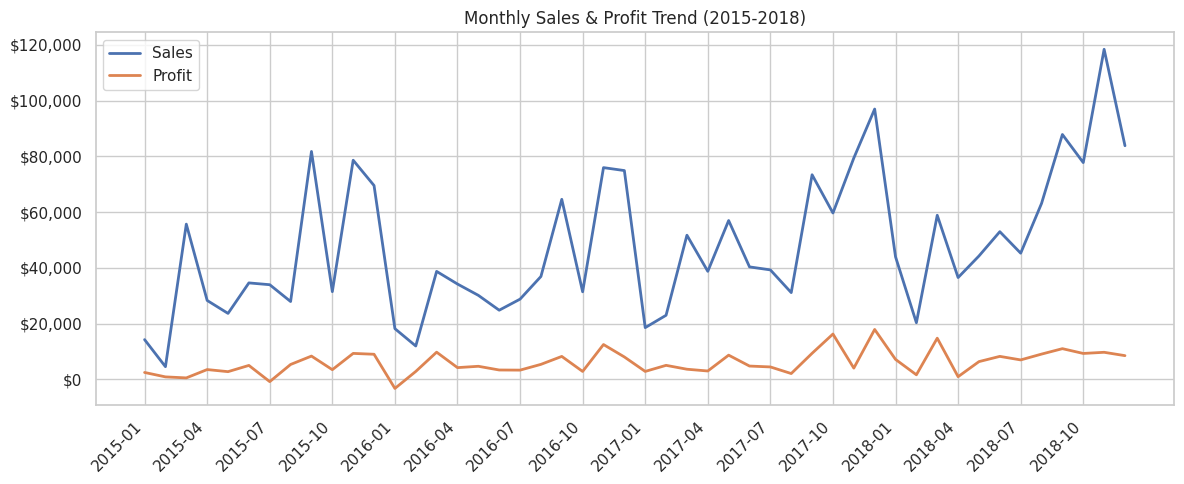

In [10]:
monthly = df.groupby("order_year_month")[["sales","profit"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly["order_year_month"], monthly["sales"], label="Sales", linewidth=2)
ax.plot(monthly["order_year_month"], monthly["profit"], label="Profit", linewidth=2)
ax.set_xticks(ax.get_xticks()[::3])
plt.xticks(rotation=45, ha="right")
ax.set_title("Monthly Sales & Profit Trend (2015-2018)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Sales & Profit by Category

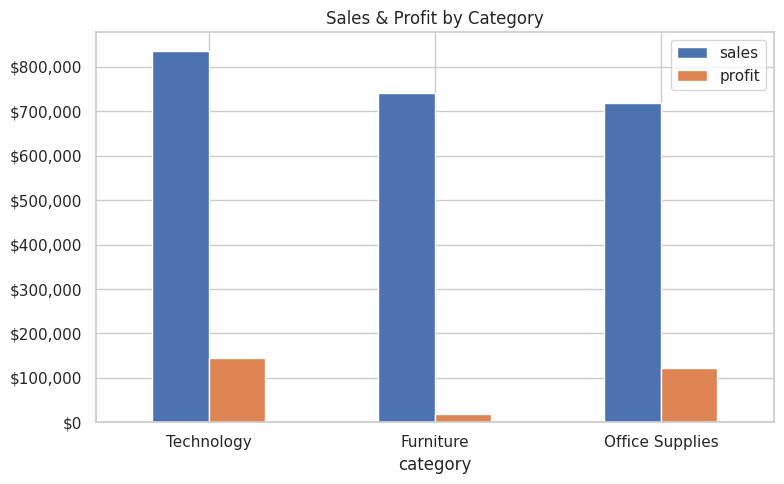

,sales,profit
category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


In [11]:
cat = df.groupby("category")[["sales","profit"]].sum().sort_values("sales", ascending=False)
ax = cat.plot(kind="bar", figsize=(8,5), title="Sales & Profit by Category")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
cat

### 4.4 Profit by Sub-Category (loss-makers highlighted)

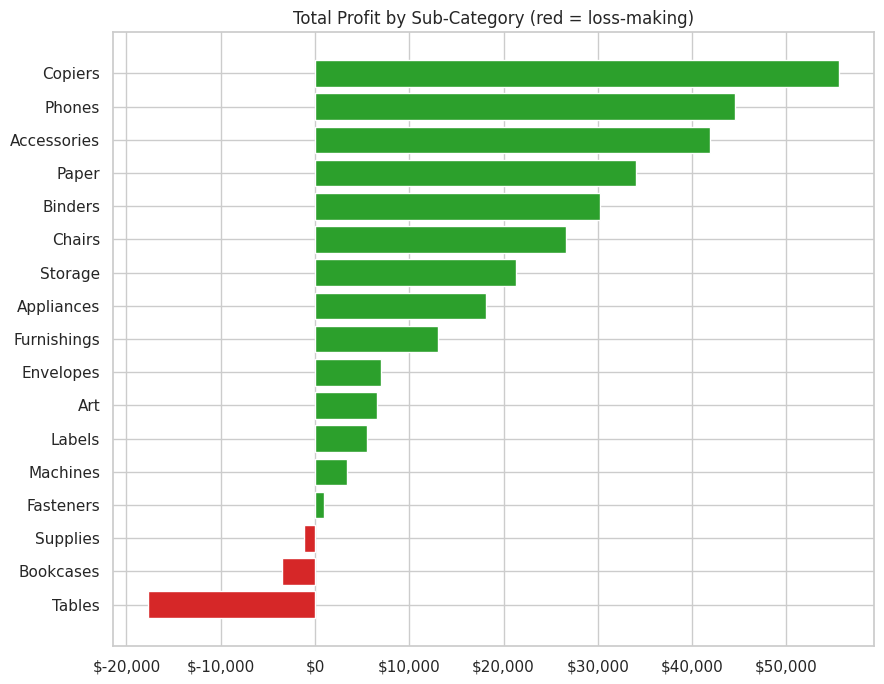

In [12]:
subcat = df.groupby("sub_category")["profit"].sum().sort_values()
colors = ["#d62728" if v < 0 else "#2ca02c" for v in subcat.values]

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(subcat.index, subcat.values, color=colors)
ax.set_title("Total Profit by Sub-Category (red = loss-making)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

**Observation:** `Tables` is the single biggest loss-maker (~ -$17.7K total), followed by `Bookcases` and `Supplies`. `Copiers`, `Phones`, and `Accessories` are the strongest profit drivers.

### 4.5 Regional Performance

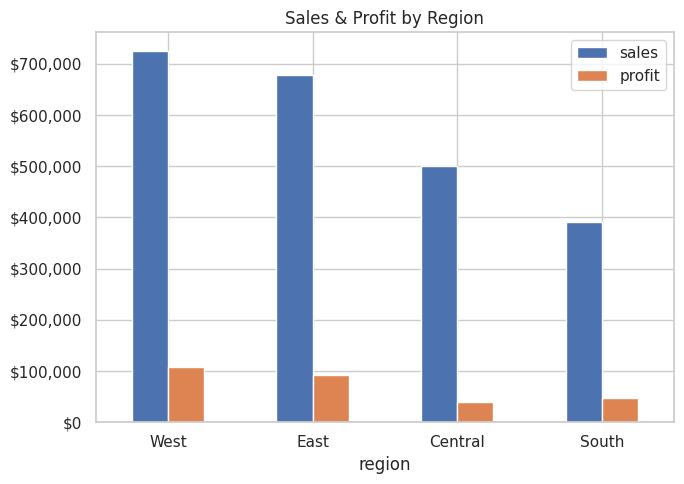

,sales,profit
region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [13]:
reg = df.groupby("region")[["sales","profit"]].sum().sort_values("sales", ascending=False)
ax = reg.plot(kind="bar", figsize=(7,5), title="Sales & Profit by Region")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
reg

### 4.6 Discount vs Profit

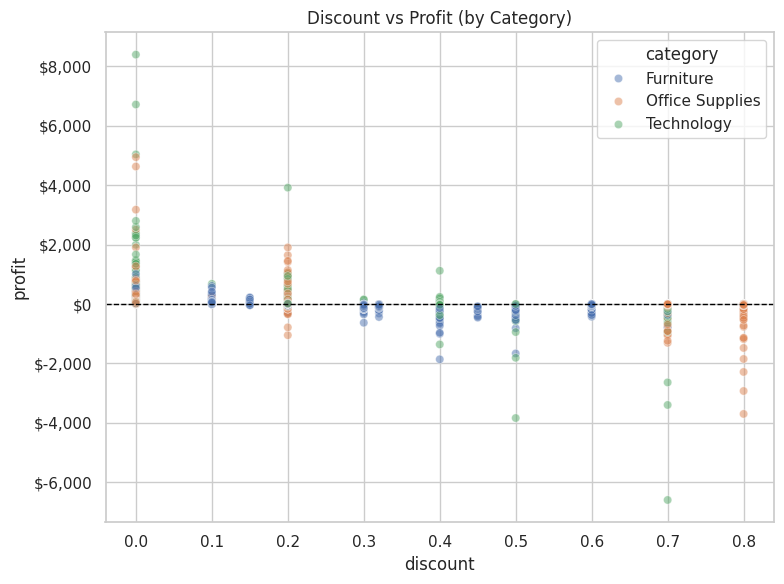

Correlation (discount, profit): -0.219


In [14]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(data=df, x="discount", y="profit", hue="category", alpha=0.5, ax=ax)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Discount vs Profit (by Category)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print("Correlation (discount, profit):", round(df["discount"].corr(df["profit"]), 3))

**Observation:** Discount and profit are negatively correlated (≈ -0.22). Heavy discounting (>30-40%) pushes many orders into a loss, especially in Furniture.

### 4.7 Customer Segment Share

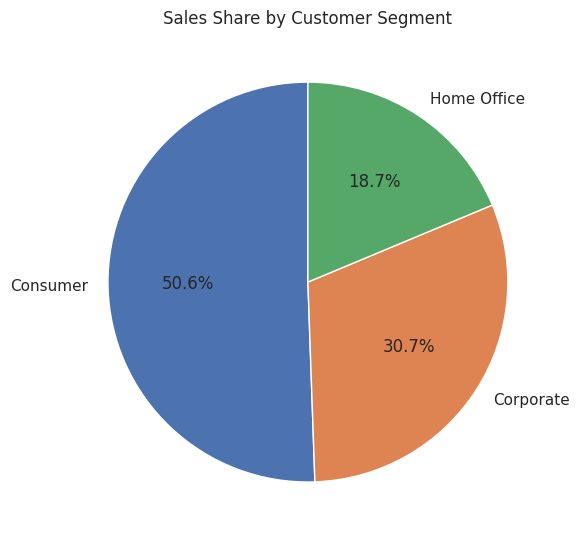

In [15]:
seg = df.groupby("segment")["sales"].sum()
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(seg.values, labels=seg.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Sales Share by Customer Segment")
plt.tight_layout()
plt.show()

### 4.8 Top 10 States by Sales

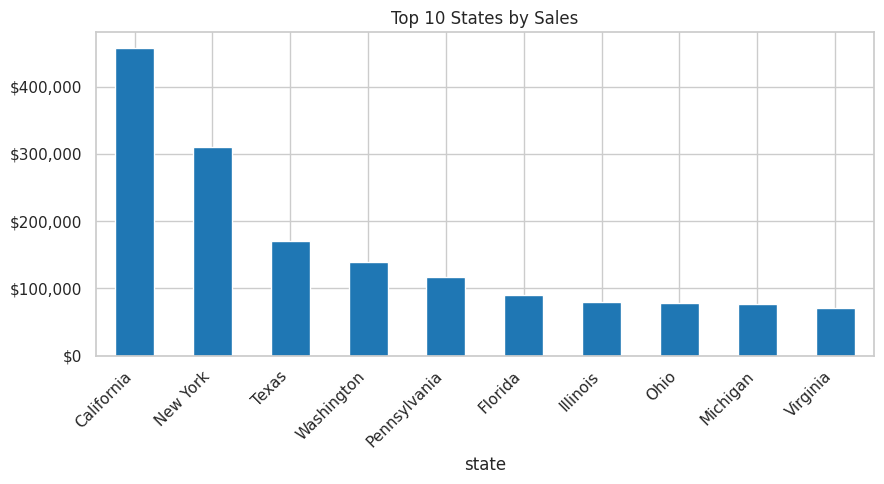

In [16]:
state = df.groupby("state")["sales"].sum().sort_values(ascending=False).head(10)
ax = state.plot(kind="bar", figsize=(9,5), color="#1f77b4", title="Top 10 States by Sales")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.9 Correlation Matrix

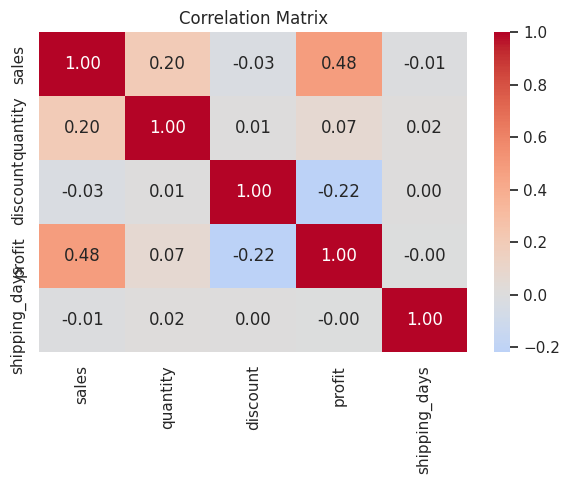

In [17]:
corr = df[["sales","quantity","discount","profit","shipping_days"]].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 5. Key Insights Summary

1. **Overall performance:** $2.30M in total sales generated $286K in profit — a modest **12.5% overall margin**.
2. **~18.7% of all orders lose money**, concentrated heavily in the Furniture category (Tables and Bookcases in particular).
3. **Discounting hurts profit:** correlation of -0.22 between discount and profit; discounts above ~30% are strongly associated with losses.
4. **Technology drives profit:** Copiers, Phones, and Accessories are the top 3 profit-generating sub-categories.
5. **Geography matters:** California and New York lead in sales, while Texas posts the weakest profit performance despite solid sales volume — a discounting/cost issue worth investigating further.
6. **Shipping:** Average shipping time is ~4 days across all ship modes, fairly consistent and not a likely driver of profit variance.

## 6. Next Steps (Task 2+)
- Deeper segmentation (customer-level RFM analysis)
- Investigate Texas / Furniture losses with a discount-threshold policy
- Build the interactive dashboard (`dashboards/`) surfacing these KPIs
